## Sección de configuración de modelo

Se usará una plantilla para todos los modelos, cambiando solo sus datos.

In [1]:
# URL del modelo: https://huggingface.co/Qwen/Qwen3.5-9B
MODEL_ID = "Qwen/Qwen3.5-9B"              # modelo a evaluar, según el id del modelo en Hugging Face
MODEL_SHORT_NAME = "qwen3_5_9b"           # nombre corto, usado para nombrar archivos de salida

SEED = 42
MAX_NEW_TOKENS = 10        # la respuesta esperada es solo la etiqueta, no necesitamos generar mucho texto
TEMPERATURE = 0.0          # determinismo: queremos la respuesta más probable, no variabilidad creativa
DO_SAMPLE = False          # con temperature=0 y do_sample=False, la generación es reproducible

RUTA_VAL = "/content/val_final.csv"
RUTA_TEST = "/content/test_final.csv"

### Dependencias

In [2]:
!pip install -q "transformers==5.10.4" accelerate "kernels==0.10.3"

import transformers
print("Versión de transformers instalada:", transformers.__version__)

import kernels
print("Versión de kernels instalada:", kernels.__version__)

import torch
print("Versión de torch instalada:", torch.__version__)

Versión de transformers instalada: 5.10.4
Versión de kernels instalada: 0.10.3
Versión de torch instalada: 2.13.0+cu130


In [3]:
import torch
print("GPU disponible:", torch.cuda.is_available())
print("Nombre GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

GPU disponible: True
Nombre GPU: NVIDIA L4


### Secreto de HF para descargar modelos

In [4]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

print("Login exitoso")

Login exitoso


### Cargar datos

In [5]:
import pandas as pd

df_val = pd.read_csv(RUTA_VAL)

print("Validation cargado:", df_val.shape)
print(df_val["label_name"].value_counts())
df_val.head()

Validation cargado: (1454, 4)
label_name
negative    663
positive    473
neutral     318
Name: count, dtype: int64


,text,text_clean,label,label_name
0,"Daniella, un sanguchito de pavo en Astoria y l...","Daniella, un sanguchito de pavo en Astoria y l...",2,positive
1,Cocoros 🙂. Cuando vivía en talara era mi punto.,Cocoros 🙂. Cuando vivía en talara era mi punto.,1,neutral
2,Jaja se elegierón los corruptos al asu aliado ...,Jaja se elegierón los corruptos al asu aliado ...,0,negative
3,"Fatima, la caminada en tacos fue todo! Ya me...","Fatima, la caminada en tacos fue todo! Ya me v...",1,neutral
4,"El injerto resollaba, emitía grititos destempl...","El injerto resollaba, emitía grititos destempl...",0,negative


## Cargamos prompts

In [6]:
PROMPTS = {
    1: {
        "system": None,
        "user": "Clasifica el sentimiento del siguiente comentario. Responde solo con una de estas palabras: negativo, neutral, positivo. Comentario: {text}"
    },
    2: {
        "system": None,
        "user": "Para el texto proporcionado, analiza su sentimiento y clasifícalo únicamente en una de las siguientes clases: negativo, neutral, positivo. Texto: {text}"
    },
    3: {
        "system": None,
        "user": "Clasifica el sentimiento del texto en español peruano informal en solo una de las siguientes categorías: negativo, neutral, positivo. Texto: {text}"
    },
    4: {
        "system": "Eres un clasificador de sentimientos de comentarios en español peruano. Responde únicamente con una de las siguientes clases: negativo, neutral, positivo.",
        "user": "Clasifica el siguiente comentario. Comentario: {text}"
    },
    5: {
        "system": "Eres un experto en clasificar el sentimiento de textos que pueden contener jergas o expresiones coloquiales del español peruano. Responde únicamente con una de las siguientes clases: negativo, neutral, positivo. No brindes texto adicional.",
        "user": "Clasifica el siguiente texto. Texto: {text}"
    },
}

def construir_mensajes(prompt_id: int, texto: str):
    """Devuelve la lista de mensajes (formato chat) para un prompt_id y un texto dado."""
    config = PROMPTS[prompt_id]
    mensajes = []
    if config["system"] is not None:
        mensajes.append({"role": "system", "content": config["system"]})
    mensajes.append({"role": "user", "content": config["user"].format(text=texto)})
    return mensajes


# Prueba rápida con un ejemplo del dataset
texto_ejemplo = df_val.iloc[0]["text_clean"]
for pid in PROMPTS:
    print(f"--- Prompt {pid} ---")
    print(construir_mensajes(pid, texto_ejemplo))
    print()

--- Prompt 1 ---
[{'role': 'user', 'content': 'Clasifica el sentimiento del siguiente comentario. Responde solo con una de estas palabras: negativo, neutral, positivo. Comentario: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 2 ---
[{'role': 'user', 'content': 'Para el texto proporcionado, analiza su sentimiento y clasifícalo únicamente en una de las siguientes clases: negativo, neutral, positivo. Texto: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 3 ---
[{'role': 'user', 'content': 'Clasifica el sentimiento del texto en español peruano informal en solo una de las siguientes categorías: negativo, neutral, positivo. Texto: Daniella, un sanguchito de pavo en Astoria y las empanadas de Sorrento...uuuffffff!!!! 😙👌'}]

--- Prompt 4 ---
[{'role': 'system', 'content': 'Eres un clasificador de sentimientos de comentarios en español peruano. Responde únicamente con una de las s

# Carga de modelo

In [7]:
import time
import torch
from transformers import AutoProcessor, AutoModelForMultimodalLM

print(f"Cargando modelo: {MODEL_ID}")
t0 = time.time()

processor = AutoProcessor.from_pretrained(MODEL_ID, token=hf_token)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token,
)

tiempo_carga = time.time() - t0
model.eval()

print(f"Modelo cargado en {tiempo_carga:.1f} segundos")
print(f"Memoria GPU reservada tras cargar: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"Memoria GPU asignada tras cargar: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Cargando modelo: Qwen/Qwen3.5-9B


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.13k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

Modelo cargado en 75.5 segundos
Memoria GPU reservada tras cargar: 18.83 GB
Memoria GPU asignada tras cargar: 18.82 GB


In [8]:
import random
import numpy as np

def fijar_semilla(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

fijar_semilla(SEED)

### Prueba de inferencia

Nota: Qwen trae thinking encendido, lo apagamos para limitar la salida.

In [9]:
mensajes_prueba = construir_mensajes(1, texto_ejemplo)

inputs = processor.apply_chat_template(
    mensajes_prueba,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    enable_thinking=False,   # respuesta directa, sin bloque <think>...</think>
).to(model.device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=DO_SAMPLE,
        pad_token_id=processor.tokenizer.pad_token_id if processor.tokenizer.pad_token_id is not None else processor.tokenizer.eos_token_id,
    )

respuesta = processor.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
print("--- Respuesta generada ---")
print(repr(respuesta))

--- Respuesta generada ---
'positivo\n'


### Debemos parsear la respuesta a una de las 3 clases: negativo, neutro, positivo.

Debido a que la respuesta no siempre va a ser limpia.

In [10]:
import re
import unicodedata

def normalizar_texto(texto: str) -> str:
    """minúsculas y sin tildes, para comparar de forma robusta"""
    texto = texto.lower().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def parsear_respuesta(respuesta: str) -> str:
    """
    Extrae la clase predicha (negativo/neutral/positivo) de la respuesta cruda del modelo.
    Devuelve 'invalido' si no se puede determinar con confianza.
    """
    texto = normalizar_texto(respuesta)

    tiene_negativo = bool(re.search(r"\bnegativ", texto))
    tiene_neutral = bool(re.search(r"\bneutral", texto))
    tiene_positivo = bool(re.search(r"\bpositiv", texto))

    encontrados = [
        etiqueta for etiqueta, encontrado in
        [("negative", tiene_negativo), ("neutral", tiene_neutral), ("positive", tiene_positivo)]
        if encontrado
    ]

    if len(encontrados) == 1:
        return encontrados[0]
    else:
        # 0 clases encontradas, o más de una mencionada (ambiguo) -> inválido
        return "invalido"


# Pruebas rápidas
casos_prueba = ["positivo\n", "Negativo.", "La respuesta es: NEUTRAL", "no estoy seguro", "positivo o neutral"]
for caso in casos_prueba:
    print(f"{caso!r:40} -> {parsear_respuesta(caso)}")

'positivo\n'                             -> positive
'Negativo.'                              -> negative
'La respuesta es: NEUTRAL'               -> neutral
'no estoy seguro'                        -> invalido
'positivo o neutral'                     -> invalido


## Loop de generación sobre validation, para los 5 prompts.

Barra de progreso, guardado incremental (checkpoints), registro de tiempo/memoria por corrida.

In [11]:
!pip install -q tqdm

In [12]:
import time
import torch
import pandas as pd
from tqdm.auto import tqdm

def evaluar_modelo_en_prompt(df, prompt_id, checkpoint_cada=200, nombre_archivo=None):
    """
    Corre el modelo sobre todo el dataframe `df` usando el prompt `prompt_id`.
    Devuelve un DataFrame con las predicciones, y guarda checkpoints incrementales en disco.
    """
    fijar_semilla(SEED)  # reproducibilidad: misma semilla al inicio de cada corrida

    resultados = []
    torch.cuda.reset_peak_memory_stats()
    t_inicio = time.time()

    for idx, fila in tqdm(df.iterrows(), total=len(df), desc=f"Prompt {prompt_id}"):
        texto = fila["text_clean"]
        mensajes = construir_mensajes(prompt_id, texto)

        inputs = processor.apply_chat_template(
            mensajes,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
            enable_thinking=False,
        ).to(model.device)

        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=DO_SAMPLE,
                pad_token_id=processor.tokenizer.pad_token_id if processor.tokenizer.pad_token_id is not None else processor.tokenizer.eos_token_id,
            )

        respuesta_cruda = processor.decode(output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
        prediccion = parsear_respuesta(respuesta_cruda)

        resultados.append({
            "idx_original": idx,
            "text_clean": texto,
            "label_name": fila["label_name"],
            "prompt_id": prompt_id,
            "respuesta_cruda": respuesta_cruda,
            "prediccion": prediccion,
        })

        # Checkpoint incremental, por si la sesión se corta
        if nombre_archivo and (len(resultados) % checkpoint_cada == 0):
            pd.DataFrame(resultados).to_csv(nombre_archivo, index=False)

    tiempo_total = time.time() - t_inicio
    memoria_pico_gb = torch.cuda.max_memory_allocated() / 1e9

    df_resultados = pd.DataFrame(resultados)
    if nombre_archivo:
        df_resultados.to_csv(nombre_archivo, index=False)

    metadata = {
        "modelo": MODEL_ID,
        "prompt_id": prompt_id,
        "seed": SEED,
        "max_new_tokens": MAX_NEW_TOKENS,
        "temperature": TEMPERATURE,
        "do_sample": DO_SAMPLE,
        "n_ejemplos": len(df),
        "tiempo_total_seg": round(tiempo_total, 1),
        "tiempo_promedio_por_ejemplo_seg": round(tiempo_total / len(df), 3),
        "memoria_pico_gb": round(memoria_pico_gb, 2),
    }

    return df_resultados, metadata

### Corremos los 5 prompts sobre validation, guardando cada uno por separadop

In [13]:
resultados_por_prompt = {}
log_experimentos = []

for prompt_id in PROMPTS:
    nombre_archivo = f"val_{MODEL_SHORT_NAME}_prompt{prompt_id}.csv"
    df_res, metadata = evaluar_modelo_en_prompt(
        df_val, prompt_id, checkpoint_cada=200, nombre_archivo=nombre_archivo
    )
    resultados_por_prompt[prompt_id] = df_res
    log_experimentos.append(metadata)
    print(f"Prompt {prompt_id} terminado -> {metadata}")

df_log = pd.DataFrame(log_experimentos)
df_log.to_csv(f"log_experimentos_{MODEL_SHORT_NAME}_validation.csv", index=False)
df_log

Prompt 1:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 1 terminado -> {'modelo': 'Qwen/Qwen3.5-9B', 'prompt_id': 1, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 841.3, 'tiempo_promedio_por_ejemplo_seg': 0.579, 'memoria_pico_gb': 19.34}


Prompt 2:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 2 terminado -> {'modelo': 'Qwen/Qwen3.5-9B', 'prompt_id': 2, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 839.1, 'tiempo_promedio_por_ejemplo_seg': 0.577, 'memoria_pico_gb': 19.36}


Prompt 3:   0%|          | 0/1454 [00:00<?, ?it/s]

...

Prompt 4:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 4 terminado -> {'modelo': 'Qwen/Qwen3.5-9B', 'prompt_id': 4, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 838.3, 'tiempo_promedio_por_ejemplo_seg': 0.577, 'memoria_pico_gb': 19.36}


Prompt 5:   0%|          | 0/1454 [00:00<?, ?it/s]

Prompt 5 terminado -> {'modelo': 'Qwen/Qwen3.5-9B', 'prompt_id': 5, 'seed': 42, 'max_new_tokens': 10, 'temperature': 0.0, 'do_sample': False, 'n_ejemplos': 1454, 'tiempo_total_seg': 852.4, 'tiempo_promedio_por_ejemplo_seg': 0.586, 'memoria_pico_gb': 19.37}


,modelo,prompt_id,seed,max_new_tokens,temperature,do_sample,n_ejemplos,tiempo_total_seg,tiempo_promedio_por_ejemplo_seg,memoria_pico_gb
0,Qwen/Qwen3.5-9B,1,42,10,0.0,False,1454,841.3,0.579,19.34
1,Qwen/Qwen3.5-9B,2,42,10,0.0,False,1454,839.1,0.577,19.36
2,Qwen/Qwen3.5-9B,3,42,10,0.0,False,1454,836.2,0.575,19.34
3,Qwen/Qwen3.5-9B,4,42,10,0.0,False,1454,838.3,0.577,19.36
4,Qwen/Qwen3.5-9B,5,42,10,0.0,False,1454,852.4,0.586,19.37


### Calcular métricas por prompt para elegir el mejor

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd

CLASES = ["negative", "neutral", "positive"]

def calcular_metricas(df_resultados, prompt_id):
    """
    Calcula métricas de clasificación. Las predicciones 'invalido' se tratan como
    errores (no coinciden con ninguna clase real), penalizando al modelo por no
    responder de forma parseable -- esto también es información relevante a reportar.
    """
    y_true = df_resultados["label_name"]
    y_pred = df_resultados["prediccion"]

    n_invalidos = (y_pred == "invalido").sum()
    pct_invalidos = round(100 * n_invalidos / len(df_resultados), 2)

    reporte = classification_report(
        y_true, y_pred, labels=CLASES, output_dict=True, zero_division=0
    )

    macro_f1 = f1_score(y_true, y_pred, labels=CLASES, average="macro", zero_division=0)

    matriz = confusion_matrix(y_true, y_pred, labels=CLASES)

    resumen = {
        "prompt_id": prompt_id,
        "accuracy": round(reporte["accuracy"], 4),
        "macro_f1": round(macro_f1, 4),
        "precision_negative": round(reporte["negative"]["precision"], 4),
        "recall_negative": round(reporte["negative"]["recall"], 4),
        "f1_negative": round(reporte["negative"]["f1-score"], 4),
        "precision_neutral": round(reporte["neutral"]["precision"], 4),
        "recall_neutral": round(reporte["neutral"]["recall"], 4),
        "f1_neutral": round(reporte["neutral"]["f1-score"], 4),
        "precision_positive": round(reporte["positive"]["precision"], 4),
        "recall_positive": round(reporte["positive"]["recall"], 4),
        "f1_positive": round(reporte["positive"]["f1-score"], 4),
        "pct_invalidos": pct_invalidos,
    }

    return resumen, matriz


resumenes = []
matrices = {}

for prompt_id in PROMPTS:
    df_res = resultados_por_prompt[prompt_id]
    resumen, matriz = calcular_metricas(df_res, prompt_id)
    resumenes.append(resumen)
    matrices[prompt_id] = matriz

df_comparacion_prompts = pd.DataFrame(resumenes)
df_comparacion_prompts.to_csv(f"comparacion_prompts_{MODEL_SHORT_NAME}_validation.csv", index=False)
df_comparacion_prompts

,prompt_id,accuracy,macro_f1,precision_negative,recall_negative,f1_negative,precision_neutral,recall_neutral,f1_neutral,precision_positive,recall_positive,f1_positive,pct_invalidos
0,1,0.6747,0.6073,0.8437,0.7164,0.7749,0.5548,0.2547,0.3491,0.5705,0.8985,0.6979,0.0
1,2,0.6492,0.5954,0.8776,0.6380,0.7389,0.5353,0.2862,0.3730,0.5362,0.9091,0.6745,0.0
2,3,0.6100,0.5263,0.8742,0.5867,0.7022,0.6133,0.1447,0.2341,0.4839,0.9556,0.6425,0.0
3,4,0.6589,0.6075,0.8814,0.6501,0.7483,0.5511,0.3050,0.3927,0.5450,0.9091,0.6815,0.0
4,5,0.6197,0.5367,0.8627,0.6063,0.7121,0.6125,0.1541,0.2462,0.4956,0.9514,0.6517,0.0


In [15]:
# Identificar el mejor prompt para este modelo, según macro-F1
mejor_prompt = df_comparacion_prompts.loc[df_comparacion_prompts["macro_f1"].idxmax(), "prompt_id"]
print(f"Mejor prompt para {MODEL_ID} (según macro-F1 en validation): Prompt {mejor_prompt}")
df_comparacion_prompts.sort_values("macro_f1", ascending=False)

Mejor prompt para Qwen/Qwen3.5-9B (según macro-F1 en validation): Prompt 4


,prompt_id,accuracy,macro_f1,precision_negative,recall_negative,f1_negative,precision_neutral,recall_neutral,f1_neutral,precision_positive,recall_positive,f1_positive,pct_invalidos
3,4,0.6589,0.6075,0.8814,0.6501,0.7483,0.5511,0.3050,0.3927,0.5450,0.9091,0.6815,0.0
0,1,0.6747,0.6073,0.8437,0.7164,0.7749,0.5548,0.2547,0.3491,0.5705,0.8985,0.6979,0.0
1,2,0.6492,0.5954,0.8776,0.6380,0.7389,0.5353,0.2862,0.3730,0.5362,0.9091,0.6745,0.0
4,5,0.6197,0.5367,0.8627,0.6063,0.7121,0.6125,0.1541,0.2462,0.4956,0.9514,0.6517,0.0
2,3,0.6100,0.5263,0.8742,0.5867,0.7022,0.6133,0.1447,0.2341,0.4839,0.9556,0.6425,0.0


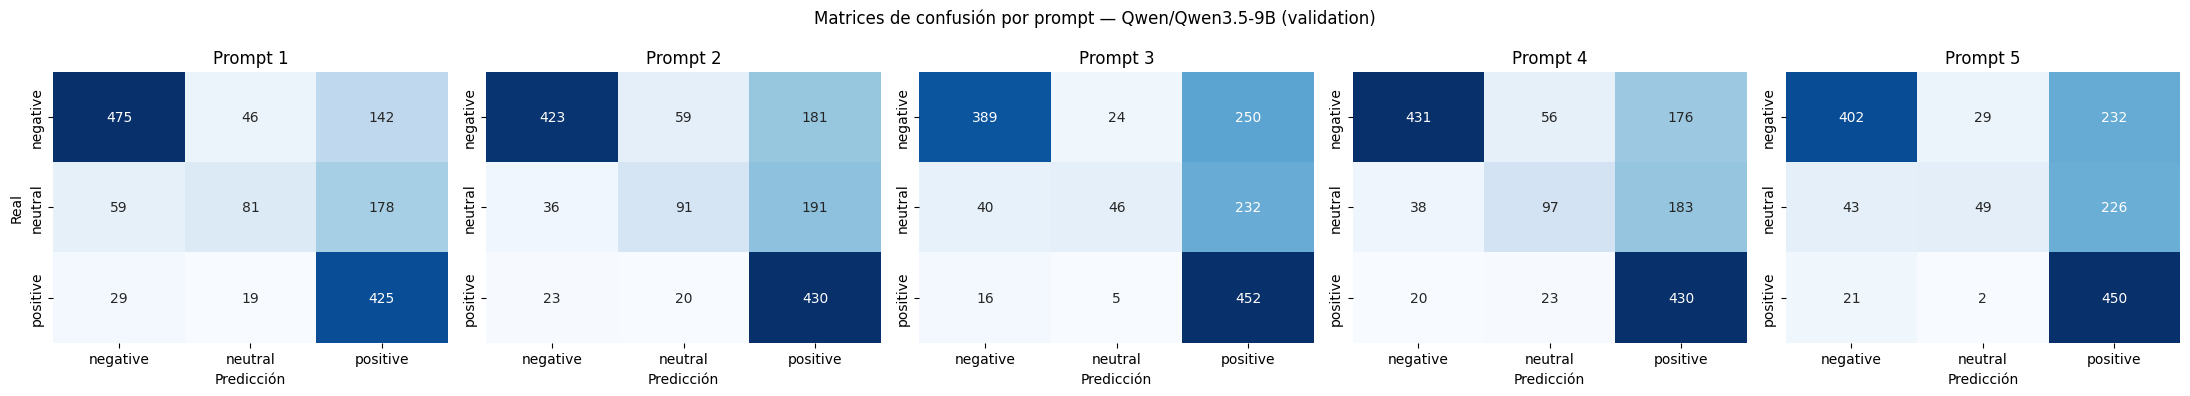

In [16]:
# Matrices de confusión de los 5 prompts
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, prompt_id in enumerate(PROMPTS):
    sns.heatmap(
        matrices[prompt_id], annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASES, yticklabels=CLASES, ax=axes[i], cbar=False
    )
    axes[i].set_title(f"Prompt {prompt_id}")
    axes[i].set_xlabel("Predicción")
    if i == 0:
        axes[i].set_ylabel("Real")

plt.suptitle(f"Matrices de confusión por prompt — {MODEL_ID} (validation)")
plt.tight_layout()
plt.savefig(f"matrices_confusion_{MODEL_SHORT_NAME}_validation.png", dpi=150)
plt.show()

Concluímos que el mejor prompt es el 4, con un macro_F1 de 0.6075 seguido del prompt 1 con 0.6073

In [17]:
import platform

metadata_carga_modelo = {
    "modelo": MODEL_ID,
    "gpu": torch.cuda.get_device_name(0),
    "tiempo_carga_modelo_seg": round(tiempo_carga, 1),
    "memoria_carga_modelo_gb": round(torch.cuda.memory_allocated() / 1e9, 2),
    "transformers_version": transformers.__version__,
    "torch_version": torch.__version__,
}

# Agregamos esta info como columnas repetidas en cada fila del log (para tener todo junto en un solo archivo)
for clave, valor in metadata_carga_modelo.items():
    df_log[clave] = valor

df_log.to_csv(f"log_experimentos_{MODEL_SHORT_NAME}_validation.csv", index=False)
df_log

,modelo,prompt_id,seed,max_new_tokens,temperature,do_sample,n_ejemplos,tiempo_total_seg,tiempo_promedio_por_ejemplo_seg,memoria_pico_gb,gpu,tiempo_carga_modelo_seg,memoria_carga_modelo_gb,transformers_version,torch_version
0,Qwen/Qwen3.5-9B,1,42,10,0.0,False,1454,841.3,0.579,19.34,NVIDIA L4,75.5,18.83,5.10.4,2.13.0+cu130
1,Qwen/Qwen3.5-9B,2,42,10,0.0,False,1454,839.1,0.577,19.36,NVIDIA L4,75.5,18.83,5.10.4,2.13.0+cu130
2,Qwen/Qwen3.5-9B,3,42,10,0.0,False,1454,836.2,0.575,19.34,NVIDIA L4,75.5,18.83,5.10.4,2.13.0+cu130
3,Qwen/Qwen3.5-9B,4,42,10,0.0,False,1454,838.3,0.577,19.36,NVIDIA L4,75.5,18.83,5.10.4,2.13.0+cu130
4,Qwen/Qwen3.5-9B,5,42,10,0.0,False,1454,852.4,0.586,19.37,NVIDIA L4,75.5,18.83,5.10.4,2.13.0+cu130
